In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Load data
df = pd.read_csv('raw_data/combined_energy_price_clean.csv', sep='\t')
df.head()

/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
/var/folders/6p/0b4w1hy94rg79cl81qv1csjc0000gn/T/ipykernel_88852/3101449309.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('raw_data/combined_energy_price_clean.csv', sep='\t')


,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC)
0,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-04 23:00:00,PT60M,DE-AT-LU,,22.34,2024-10-03 13:21:54
1,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 00:00:00,PT60M,DE-AT-LU,,17.93,2024-10-03 13:21:54
2,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 01:00:00,PT60M,DE-AT-LU,,15.17,2024-10-03 13:21:54
3,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 02:00:00,PT60M,DE-AT-LU,,16.38,2024-10-03 13:21:54
4,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 03:00:00,PT60M,DE-AT-LU,,17.38,2024-10-03 13:21:54


In [47]:
# Prophet requiere columns 'ds' y 'y'
prophet_df = df[df['Sequence']==2][['DateTime(UTC)', 'Price[Currency/MWh]']].copy()
prophet_df.columns = ['ds', 'y']

# add date time
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Checks for nuls
prophet_df = prophet_df.dropna().sort_values('ds').reset_index(drop=True)

print(prophet_df.shape)
prophet_df.head()

(186230, 2)


,ds,y
0,2020-12-29 00:30:00,35.23
1,2020-12-29 00:45:00,29.68
2,2020-12-29 01:00:00,42.18
3,2020-12-29 01:15:00,36.62
4,2020-12-29 01:30:00,33.07


In [48]:
print(prophet_df['ds'].min(), '...', prophet_df['ds'].max())

2020-12-29 00:30:00 ... 2026-04-21 21:45:00


In [ ]:
# Fusionar Sequence 2 (2020+) con Sequence vacía (pre-2020)
df_fused = df[df['Sequence'].isin([2, ' '])][['DateTime(UTC)', 'Price[Currency/MWh]']].copy()
df_fused.columns = ['ds', 'y']
df_fused['ds'] = pd.to_datetime(df_fused['ds'])
df_fused = df_fused.dropna().sort_values('ds').drop_duplicates('ds').reset_index(drop=True)

print(df_fused.shape)
print(df_fused['ds'].min(), '→', df_fused['ds'].max())

(218989, 2)
2015-01-04 23:00:00 → 2026-04-21 21:45:00


In [50]:
prophet_df = df_fused.set_index('ds').resample('h').mean().reset_index()
prophet_df = prophet_df.dropna().reset_index(drop=True)

print(prophet_df.shape)
print(prophet_df['ds'].min(), '→', prophet_df['ds'].max())

(79317, 2)
2015-01-04 23:00:00 → 2026-04-21 21:00:00


In [51]:
# Cap outliers
prophet_df['y'] = prophet_df['y'].clip(upper=500)

# Train/test split
train = prophet_df[prophet_df['ds'] < '2024-01-01']
test = prophet_df[prophet_df['ds'] >= '2024-01-01']

print(f'Train: {train.shape[0]} rows — {train["ds"].min()} → {train["ds"].max()}')
print(f'Test:  {test.shape[0]} rows — {test["ds"].min()} → {test["ds"].max()}')

Train: 59111 rows — 2015-01-04 23:00:00 → 2023-12-31 23:00:00
Test:  20206 rows — 2024-01-01 00:00:00 → 2026-04-21 21:00:00


In [52]:
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
model.fit(train)

16:51:26 - cmdstanpy - INFO - Chain [1] start processing
16:51:42 - cmdstanpy - INFO - Chain [1] done processing


/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packag

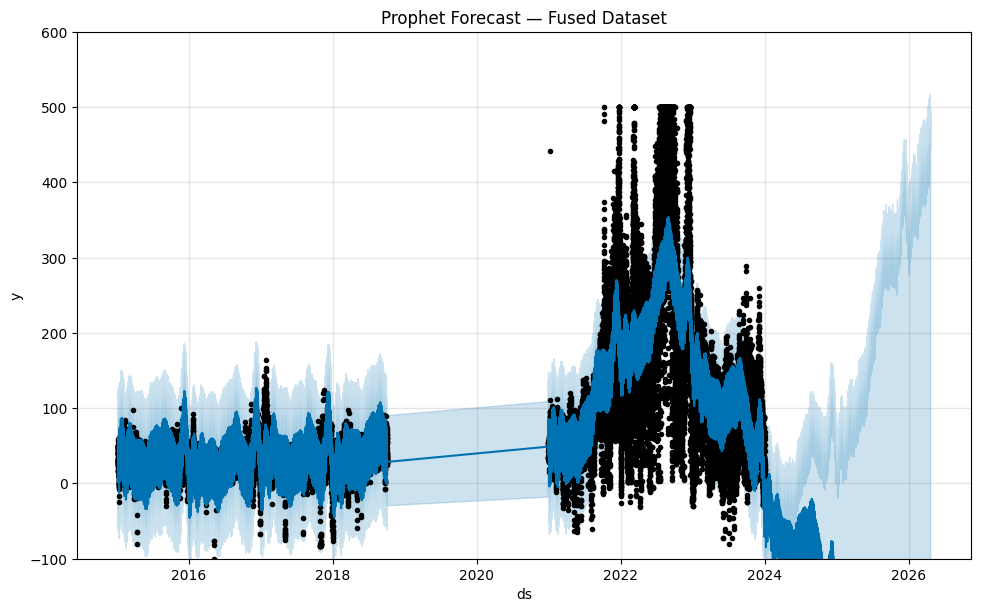

In [53]:
future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)

model.plot(forecast)
plt.ylim(-100, 600)
plt.title('Prophet Forecast — Fused Dataset')
plt.show()

In [39]:
print(df['AreaDisplayName'].value_counts())

AreaDisplayName
DE-LU       345548
DE-AT-LU     32759
Name: count, dtype: int64


## Full Dataset

In [27]:
prophet_df_capped = prophet_df.copy()
prophet_df_capped['y'] = prophet_df_capped['y'].clip(upper=500)

# Nuevo train/test
train_capped = prophet_df_capped[prophet_df_capped['ds'] < '2024-01-01']
test_capped = prophet_df_capped[prophet_df_capped['ds'] >= '2024-01-01']

# Fit
model_capped = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
model_capped.fit(train_capped)

16:06:57 - cmdstanpy - INFO - Chain [1] start processing
16:07:31 - cmdstanpy - INFO - Chain [1] done processing


/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packag

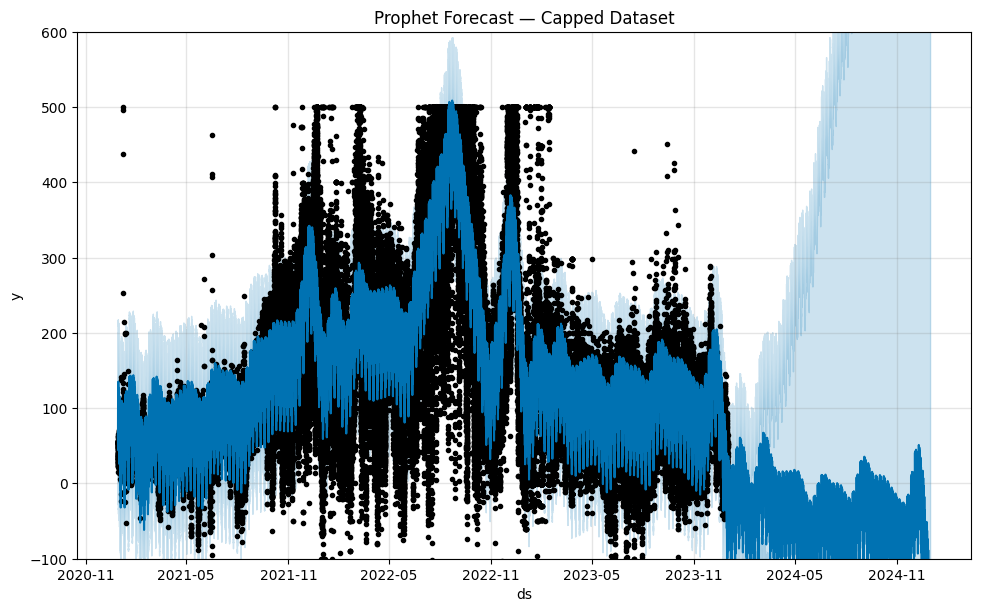

In [18]:
future_capped = model_capped.make_future_dataframe(periods=8760, freq='h')  # 1 year
forecast_capped = model_capped.predict(future_capped)
model_capped.plot(forecast_capped)
plt.ylim(-100, 600)  # fixing the scale
plt.title('Prophet Forecast — Capped Dataset')
plt.show()

15:36:11 - cmdstanpy - INFO - Chain [1] start processing
15:36:11 - cmdstanpy - INFO - Chain [1] done processing
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_feat

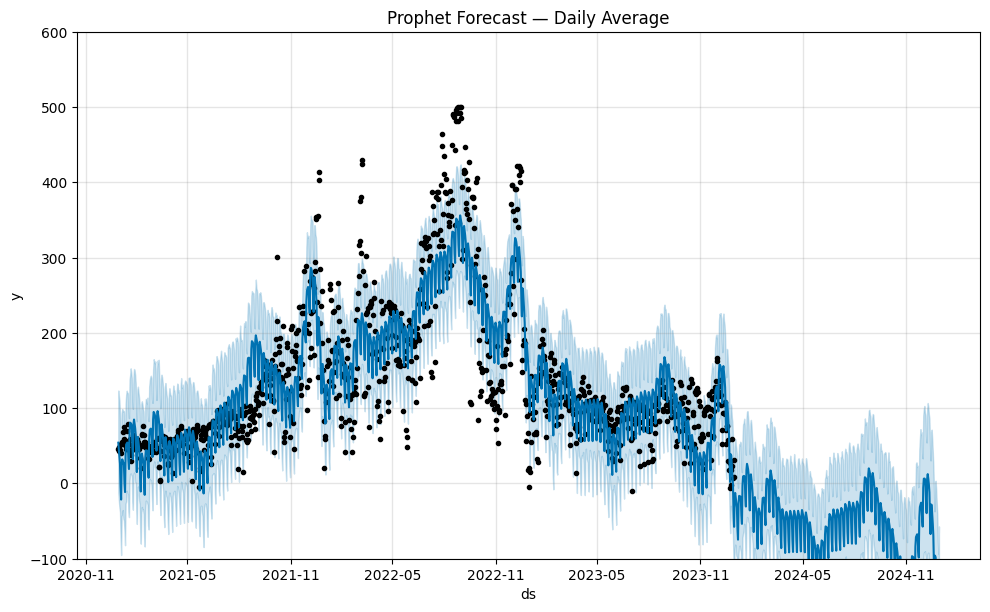

In [19]:
prophet_daily = prophet_df_capped.resample('D', on='ds').mean().reset_index()

train_daily = prophet_daily[prophet_daily['ds'] < '2024-01-01']

model_daily = Prophet(weekly_seasonality=True, yearly_seasonality=True)
model_daily.fit(train_daily)

future_daily = model_daily.make_future_dataframe(periods=365, freq='D')
forecast_daily = model_daily.predict(future_daily)

model_daily.plot(forecast_daily)
plt.ylim(-100, 600)
plt.title('Prophet Forecast — Daily Average')
plt.show()

/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())


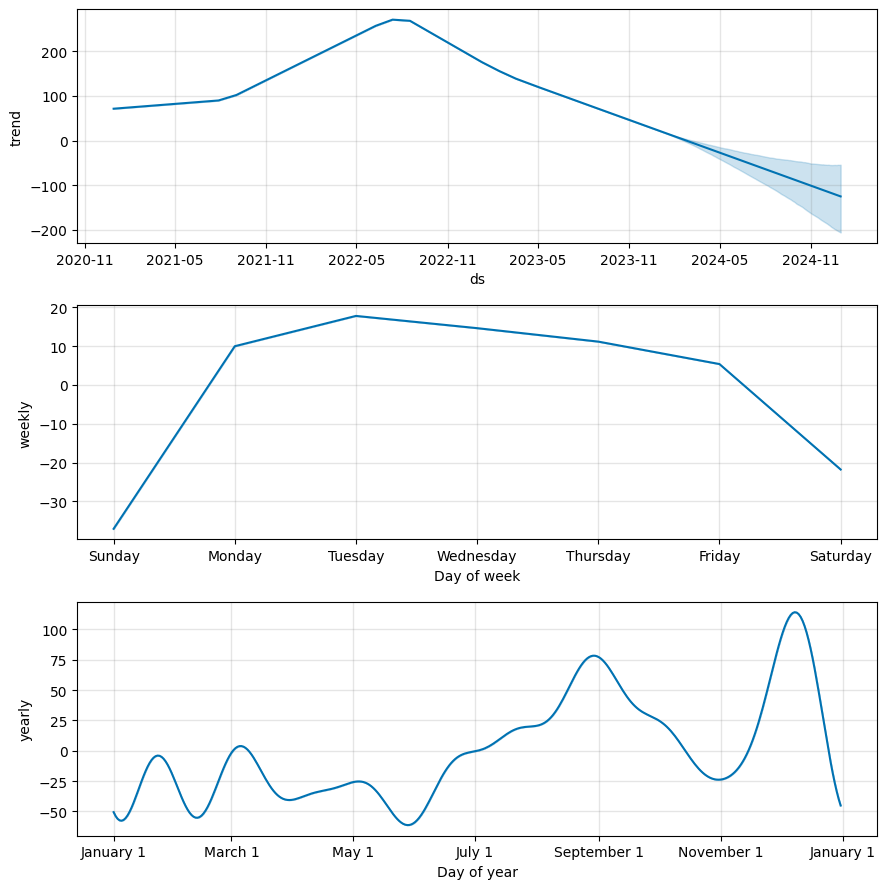

In [20]:
model_daily.plot_components(forecast_daily)
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predicciones vs real en el período de test
forecast_test = forecast_daily[forecast_daily['ds'] >= '2024-01-01'][['ds', 'yhat']]
test_daily = prophet_daily[prophet_daily['ds'] >= '2024-01-01']

merged = test_daily.merge(forecast_test, on='ds')

mae = mean_absolute_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))

print(f'MAE:  {mae:.2f} EUR/MWh')
print(f'RMSE: {rmse:.2f} EUR/MWh')

MAE:  129.51 EUR/MWh
RMSE: 138.68 EUR/MWh


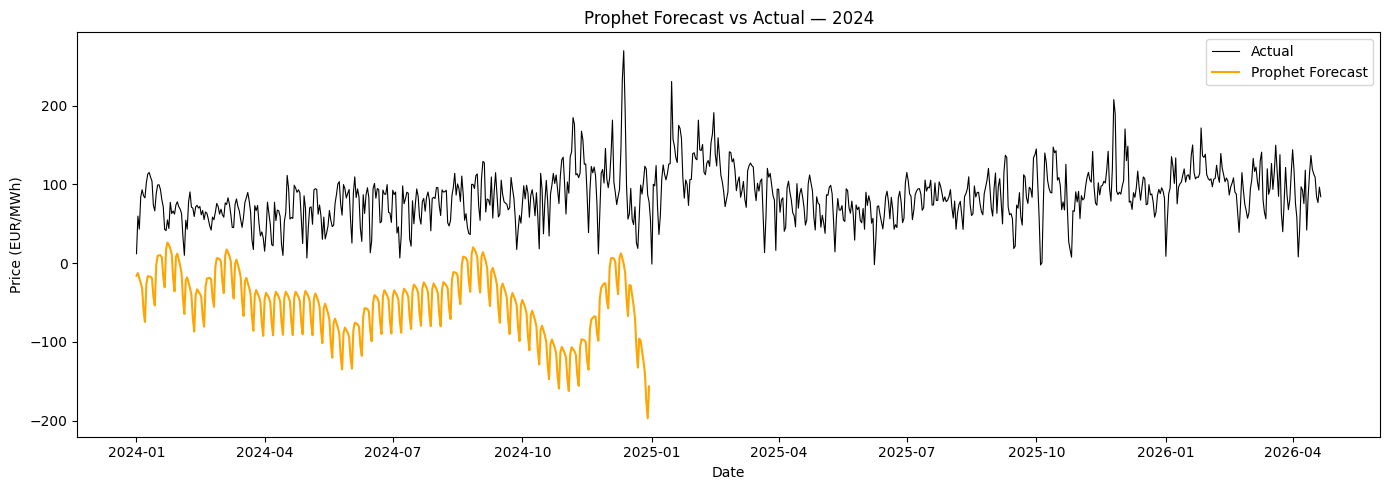

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_daily['ds'], test_daily['y'], label='Actual', color='black', linewidth=0.8)
ax.plot(merged['ds'], merged['yhat'], label='Prophet Forecast', color='orange', linewidth=1.5)

ax.set_title('Prophet Forecast vs Actual — 2024')
ax.set_ylabel('Price (EUR/MWh)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model_daily,
    initial='2555 days',  # ~7 años de train
    period='30 days',
    horizon='365 days'
)

df_cv.head()

ValueError: Less data than horizon after initial window. Make horizon or initial shorter.

  horizon         mae        rmse
0 37 days  101.645786  126.132899
1 38 days  101.922939  126.165421
2 39 days  102.367160  126.279210
3 40 days  102.574447  126.344012
4 41 days  102.386285  126.194826
5 42 days  102.621668  126.523305
6 43 days  102.917764  126.976058
7 44 days  103.535154  127.888197
8 45 days  104.542207  129.154628
9 46 days  105.675252  130.367377


/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


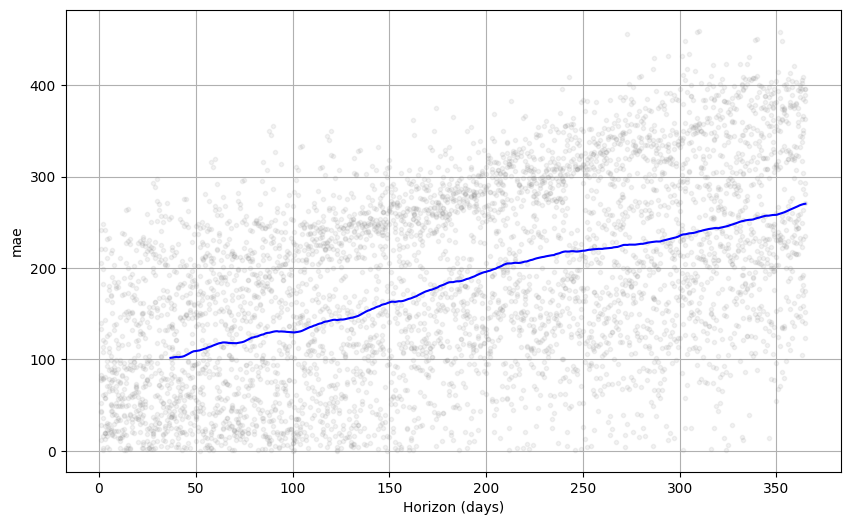

In [12]:
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric

df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'rmse']].head(10))

plot_cross_validation_metric(df_cv, metric='mae')
plt.show()